# Analysis of variance components of model ensemble data containing temporal autocorrelation

## Import packages and define the ancillary functions

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
from sklearn.feature_selection import mutual_info_regression
from statsmodels.tsa.stattools import acf


def remove_linear_trend(
    g,
    t_dim="t",
    a=0.0,
    b=0.0,
):
    """
    Remove a user-specified linear trend a + b*t from g.
    """
    t0 = pd.Timestamp(g[t_dim].values[0])

    tau = (
        pd.to_datetime(g[t_dim].values) - t0
    ) / np.timedelta64(1, "D")

    tau = xr.DataArray(
        tau.astype(float),
        dims=[t_dim],
        coords={t_dim: g[t_dim]},
    )

    trend = a + b * tau

    return g - trend




def remove_seasonal_cycle(
    g,
    t_dim="t",
):
    """
    Remove the mean seasonal cycle from monthly data.

    Assumes the time coordinate contains monthly means.
    The seasonal cycle is estimated separately for each calendar
    month using all years available in the record.
    """
    if not np.issubdtype(g[t_dim].dtype, np.datetime64):
        raise ValueError(
            f"{t_dim} must be a datetime coordinate to remove "
            "the seasonal cycle."
        )

    monthly_climatology = g.groupby(f"{t_dim}.month").mean(dim=t_dim)

    return g.groupby(f"{t_dim}.month") - monthly_climatology



def estimate_autocorrelation_timescale(x, max_lag=None):
    """
    Estimate persistence timescale from the autocorrelation function.
    Uses statsmodels.tsa.stattools.acf.
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if len(x) < 5:
        return 1

    if max_lag is None:
        max_lag = max(1, len(x) // 4)

    acf_values = acf(
        x,
        nlags=max_lag,
        fft=True,
        missing="drop",
    )

    below_threshold = np.where(acf_values < np.exp(-1))[0]

    if len(below_threshold) == 0:
        print('Warning: autocorrelation timescale indeterminate - therefore \
        using max_lag = ',max_lag)
        
        return max_lag

    return int(max(1, below_threshold[0]))



def estimate_mutual_information_timescale(x, max_lag=None):
    """
    Estimate persistence timescale using lagged mutual information.
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if len(x) < 10:
        return 1

    if max_lag is None:
        max_lag = max(2, len(x) // 4)

    mi = []

    for lag in range(1, max_lag + 1):
        x1 = x[:-lag]
        x2 = x[lag:]

        if len(x1) < 5:
            mi.append(np.nan)
            continue

        score = mutual_info_regression(
            x1.reshape(-1, 1),
            x2,
            discrete_features=False,
            random_state=0,
        )[0]

        mi.append(score)

    mi = np.asarray(mi)

    valid = np.isfinite(mi)
    if not np.any(valid):
        return 1

    threshold = np.exp(-1) * mi[valid][0]

    below_threshold = np.where(mi < threshold)[0]

    if len(below_threshold) == 0:
        print('Warning: mutual information timescale indeterminate - therefore \
        using max_lag = ',max_lag)
        
        return max_lag

    return int(max(1, below_threshold[0] + 1))



def estimate_window_width(
    g,
    j_dim="j",
    k_dim="k",
    t_dim="t",
    max_lag=None,
    persistence_factor=4,
    quantile=0.75,
    detrend=False,
    a=0.0,
    b=0.0,
):
    """
    Estimate moving-window width from persistence diagnostics.
    """
    if detrend:
        g = remove_linear_trend(
            g,
            t_dim=t_dim,
            a=a,
            b=b,
        )

    acf_scales = []
    mi_scales = []

    for j in g[j_dim].values:
        for k in g[k_dim].values:
            x = g.sel({j_dim: j, k_dim: k}).values

            acf_scales.append(
                estimate_autocorrelation_timescale(
                    x,
                    max_lag=max_lag,
                )
            )

            mi_scales.append(
                estimate_mutual_information_timescale(
                    x,
                    max_lag=max_lag,
                )
            )

    acf_scales = np.asarray(acf_scales)
    mi_scales = np.asarray(mi_scales)

    representative_acf = int(
        np.ceil(np.quantile(acf_scales, quantile))
    )
    representative_mi = int(
        np.ceil(np.quantile(mi_scales, quantile))
    )

    dominant_scale = max(representative_acf, representative_mi)

    window_width = max(
        3,
        int(np.ceil(persistence_factor * dominant_scale))
    )

    return {
        "acf_timescales": acf_scales,
        "mi_timescales": mi_scales,
        "representative_acf": representative_acf,
        "representative_mi": representative_mi,
        "dominant_persistence_scale": dominant_scale,
        "recommended_window_width": window_width,
    }



def moving_block_bootstrap_indices(
    n,
    block_length,
    rng=None,
):
    """
    Generate moving-block bootstrap indices.
    """
    if rng is None:
        rng = np.random.default_rng()

    possible_starts = np.arange(
        0,
        max(1, n - block_length + 1),
    )

    idx = []

    while len(idx) < n:
        start = rng.choice(possible_starts)

        idx.extend(
            np.arange(
                start,
                min(start + block_length, n),
            )
        )

    return np.asarray(idx[:n])



def _compute_window_statistics(
    g_win,
    j_dim,
    k_dim,
    t_dim,
):
    """
    Compute variance components for one moving window.
    """
    mean_all = g_win.mean(dim=[j_dim, k_dim, t_dim])
    mean_j = g_win.mean(dim=[k_dim, t_dim])
    mean_jk = g_win.mean(dim=t_dim)

    mean_j_expanded = mean_j.broadcast_like(mean_jk)

    variance_between_j = mean_j.var(dim=j_dim, ddof=1)

    variance_between_k_within_j = (
        mean_jk - mean_j_expanded
    ).var(dim=[j_dim, k_dim], ddof=1)

    residual = g_win - mean_jk

    residual_variance = residual.var(
        dim=[j_dim, k_dim, t_dim],
        ddof=1,
    )

    total_variance = g_win.var(
        dim=[j_dim, k_dim, t_dim],
        ddof=1,
    )

    return {
        "mean": float(mean_all.values),
        "variance_between_j": float(variance_between_j.values),
        "variance_between_k_within_j": float(
            variance_between_k_within_j.values
        ),
        "residual_variance": float(residual_variance.values),
        "total_variance": float(total_variance.values),
        "fraction_variance_between_j": float(
            (variance_between_j / total_variance).values
        ),
        "fraction_variance_between_k_within_j": float(
            (variance_between_k_within_j / total_variance).values
        ),
        "fraction_residual_variance": float(
            (residual_variance / total_variance).values
        ),
    }

## Define the main function

In [2]:
def moving_window_variance_decomposition_R(
    g,
    j_dim="j",
    k_dim="k",
    t_dim="t",
    window_width=None,
    persistence_factor=4,
    persistence_quantile=0.75,
    bootstrap=False,
    n_boot=200,
    block_length=None,
    random_seed=None,
    detrend=False,
    a=0.0,
    b=0.0,
    remove_seasonality=True,
):
    """
    Estimate time-varying variance components from a nested ensemble time series.

    The method decomposes variability within a moving temporal window into:
    (1) variance between top-level groups j,
    (2) variance between members k within each j,
    (3) residual temporal variance,
    (4) total variance,
    (5) fraction of total variance from each component (1)-(3).

    Optionally, hierarchical bootstrap confidence intervals can
    also be estimated by resampling:
    - j groups with replacement;
    - k members with replacement;
    - contiguous temporal blocks using moving-block bootstrap.
    

    Optional preprocessing includes detrending,
    and seasonal-cycle removal. 

    Parameters
    ----------
    g : xarray.DataArray
        Input data with dimensions including j, k, and t.
    window_width : int or None, optional
        Width of the moving window in samples. If None, estimated from
        persistence timescales.
    persistence_factor : float, default=4
        Factor used to convert persistence timescale into window width.
    bootstrap : bool, default=False
        If True, compute bootstrap confidence intervals.
    n_boot : int, default=200
        Number of bootstrap realizations.
    ...

    Returns
    -------
    xarray.Dataset
        Dataset containing moving-window variance components and,
        optionally, bootstrap confidence intervals.

    Notes
    -----
    The decomposition assumes a nested ensemble structure g[j, k, t].
    Window width may be estimated automatically from autocorrelation and
    mutual-information persistence timescales.

    For each time step, statistics are computed within a local
    temporal window centered on that time.

    References
    ----------
    Deser, C. et al. (2025). Climate Dynamics.
    DOI: 10.1007/s00382-024-07553-z
    """
    
    rng = np.random.default_rng(random_seed)

    # ----------------------------------------------------------
    # Optional detrending step
    # ----------------------------------------------------------
    # Remove a user-specified linear trend a + b*t before
    # estimating persistence scales and variance components.
    if detrend:
        g = remove_linear_trend(
            g,
            t_dim=t_dim,
            a=a,
            b=b,
        )


    # ----------------------------------------------------------

    # ----------------------------------------------------------
    # Optional removal of the seasonal cycle
    # ----------------------------------------------------------
    # Remove the monthly climatological seasonal cycle after any
    # detrending and ensemble-mean removal.
    if remove_seasonality:
        g = remove_seasonal_cycle(
            g,
            t_dim=t_dim,
        )

    # ----------------------------------------------------------
    # Determine moving-window width
    # ----------------------------------------------------------
    # If the user does not specify a fixed window width,
    # estimate one automatically from persistence diagnostics.
    # The dominant persistence scale is based on the larger of:
    # - autocorrelation timescale;
    # - mutual-information timescale.
    if window_width is None:
        persistence_info = estimate_window_width(
            g,
            j_dim=j_dim,
            k_dim=k_dim,
            t_dim=t_dim,
            persistence_factor=persistence_factor,
            quantile=persistence_quantile,
        )

        window_width = persistence_info[
            "recommended_window_width"
        ]
    else:
        persistence_info = None

    # ----------------------------------------------------------
    # Determine moving-block bootstrap block length
    # ----------------------------------------------------------
    # If no block length is specified, use the dominant
    # persistence scale when available. Otherwise use a
    # simple fraction of the moving-window width.
    if block_length is None:
        if persistence_info is not None:
            block_length = persistence_info[
                "dominant_persistence_scale"
            ]
        else:
            block_length = max(1, window_width // 5)

    half_window = window_width // 2
    nt = g.sizes[t_dim]

    results = {}
    output_times = []

    # ----------------------------------------------------------
    # Loop over all times and compute local statistics
    # ----------------------------------------------------------
    for it in range(nt):
        start = max(0, it - half_window)
        end = min(nt, it + half_window + 1)

        # Extract local moving window around current time
        g_win = g.isel({t_dim: slice(start, end)})

        # Compute mean and variance components for this window
        stats = _compute_window_statistics(
            g_win,
            j_dim,
            k_dim,
            t_dim,
        )

        # Append each statistic to the output dictionary
        for key, value in stats.items():
            results.setdefault(key, []).append(value)

        # ------------------------------------------------------
        # Optional hierarchical bootstrap uncertainty estimates
        # ------------------------------------------------------
        if bootstrap:
            boot_results = {
                "variance_between_j": [],
                "variance_between_k_within_j": [],
                "residual_variance": [],
                "total_variance": [],
            }

            n_j = g_win.sizes[j_dim]
            n_k = g_win.sizes[k_dim]
            n_t = g_win.sizes[t_dim]

            for _ in range(n_boot):
                # Resample j groups with replacement
                j_idx = rng.choice(
                    n_j,
                    size=n_j,
                    replace=True,
                )

                # Resample k members with replacement
                k_idx = rng.choice(
                    n_k,
                    size=n_k,
                    replace=True,
                )

                # Resample contiguous temporal blocks to preserve
                # temporal autocorrelation structure
                t_idx = moving_block_bootstrap_indices(
                    n=n_t,
                    block_length=min(block_length, n_t),
                    rng=rng,
                )

                g_boot = g_win.isel({
                    j_dim: j_idx,
                    k_dim: k_idx,
                    t_dim: t_idx,
                })

                boot_stats = _compute_window_statistics(
                    g_boot,
                    j_dim,
                    k_dim,
                    t_dim,
                )

                for key in boot_results:
                    boot_results[key].append(boot_stats[key])

            # Store 95% bootstrap confidence intervals
            for key, values in boot_results.items():
                results.setdefault(f"{key}_ci_lower", []).append(
                    np.percentile(values, 2.5)
                )
                results.setdefault(f"{key}_ci_upper", []).append(
                    np.percentile(values, 97.5)
                )

        output_times.append(g[t_dim].values[it])

    # ----------------------------------------------------------
    # Convert accumulated results to an xarray Dataset
    # ----------------------------------------------------------
    ds = xr.Dataset(
        {
            key: xr.DataArray(
                values,
                dims=[t_dim],
                coords={t_dim: output_times},
            )
            for key, values in results.items()
        }
    )


    ds.attrs["window_width"] = int(window_width)
    ds.attrs["block_length"] = int(block_length)
    ds.attrs["detrended"] = bool(detrend)
    ds.attrs["bootstrap"] = bool(bootstrap)
    ds.attrs["n_boot"] = int(n_boot)
    ds.attrs["remove_seasonality"] = bool(
        remove_seasonality
    )

    if detrend:
        ds.attrs["trend_intercept_a"] = float(a)
        ds.attrs["trend_slope_b"] = float(b)

    if persistence_info is not None:
        ds.attrs["representative_acf"] = int(
            persistence_info["representative_acf"]
        )
        ds.attrs["representative_mi"] = int(
            persistence_info["representative_mi"]
        )
        ds.attrs["dominant_persistence_scale"] = int(
            persistence_info["dominant_persistence_scale"]
        )

    return ds

## Test the function

In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt


# --------------------------------------------------------------
# Generate synthetic ensemble data
# --------------------------------------------------------------
rng = np.random.default_rng(123)

nt = 180
nj = 8
nk = 5

time = pd.date_range("2000-01-01", periods=nt, freq="MS")
t_index = np.arange(nt)

arr = np.zeros((nj, nk, nt))

# --------------------------------------------------------------
# Shared large-scale signals
# --------------------------------------------------------------

# Shared low-frequency oscillation
shared_signal = 2.0 * np.sin(2 * np.pi * t_index / 60)

# Slowly varying group-level signal
group_signal = np.sin(2 * np.pi * t_index / 90)

# Linear drift
drift = 0.01 * t_index

# Nonlinear low-frequency grand-ensemble signal
grand_ensemble_signal = (
    1.5 * np.sin(2 * np.pi * t_index / 120)
    + 0.5 * np.cos(2 * np.pi * t_index / 45)
)

# Seasonal cycle
seasonal_cycle = (
    3.0 * np.sin(2 * np.pi * t_index / 12)
    + 1.0 * np.cos(2 * np.pi * t_index / 12)
)

# --------------------------------------------------------------
# Generate ensemble members
# --------------------------------------------------------------
for j in range(nj):
    for k in range(nk):
        x = np.zeros(nt)

        # AR(1)-style temporal persistence
        noise = rng.normal(scale=0.5, size=nt)

        for t in range(1, nt):
            x[t] = 0.8 * x[t - 1] + noise[t]

        # j-level offset varies across groups
        j_offset = 0.8 * (j - (nj - 1) / 2)

        # k-level offset varies within each j
        k_offset = 0.3 * (k - (nk - 1) / 2)

        # Time-varying j-level modulation
        j_time_signal = (j / nj) * group_signal

        # Small k-dependent seasonal amplitude modulation
        k_seasonal_scaling = 1.0 + 0.1 * (k - (nk - 1) / 2)

        arr[j, k, :] = (
            shared_signal
            + grand_ensemble_signal
            + k_seasonal_scaling * seasonal_cycle
            + j_offset
            + k_offset
            + j_time_signal
            + drift
            + x
        )

g = xr.DataArray(
    arr,
    dims=["j", "k", "t"],
    coords={
        "j": np.arange(nj),
        "k": np.arange(nk),
        "t": time,
    },
    name="g",
)

print("Synthetic data shape:", g.shape)
print("Dimensions:", g.dims)
print("Time range:", str(g.t.values[0]), "to", str(g.t.values[-1]))

# --------------------------------------------------------------
# Plot example raw ensemble members
# --------------------------------------------------------------
plt.figure(figsize=(12, 5))

for j in range(min(nj, 3)):
    for k in range(min(nk, 2)):
        plt.plot(
            g.t,
            g.sel(j=j, k=k),
            alpha=0.7,
            label=f"j={j}, k={k}"
        )

plt.title("Example synthetic ensemble members")
plt.xlabel("Time")
plt.ylabel("g")
plt.legend()
plt.tight_layout()
plt.show()

# --------------------------------------------------------------
# Estimate suitable window width
# --------------------------------------------------------------
window_info = estimate_window_width(
    g,
    persistence_factor=5,
    quantile=0.75,
    detrend=True,
    a=0.0,
    b=0.01 / 30.0,  # approximate monthly drift in units/day
)

print("\nPersistence diagnostics")
print("-----------------------")
print("Representative ACF timescale:",
      window_info["representative_acf"])
print("Representative MI timescale:",
      window_info["representative_mi"])
print("Dominant persistence scale:",
      window_info["dominant_persistence_scale"])
print("Recommended window width:",
      window_info["recommended_window_width"])

# --------------------------------------------------------------
# Run moving-window decomposition with all preprocessing enabled
# --------------------------------------------------------------
result = moving_window_variance_decomposition_R(
    g,
    window_width=window_info["recommended_window_width"],
    detrend=True,
    a=0.0,
    b=0.01 / 30.0,
    remove_seasonality=True,
    bootstrap=True,
    n_boot=100,
    random_seed=123,
)

print("\nDataset returned by moving_window_variance_decomposition_R")
print("----------------------------------------------------------")
print(result)

print("\nDataset attributes")
print("------------------")
for key, value in result.attrs.items():
    print(f"{key}: {value}")

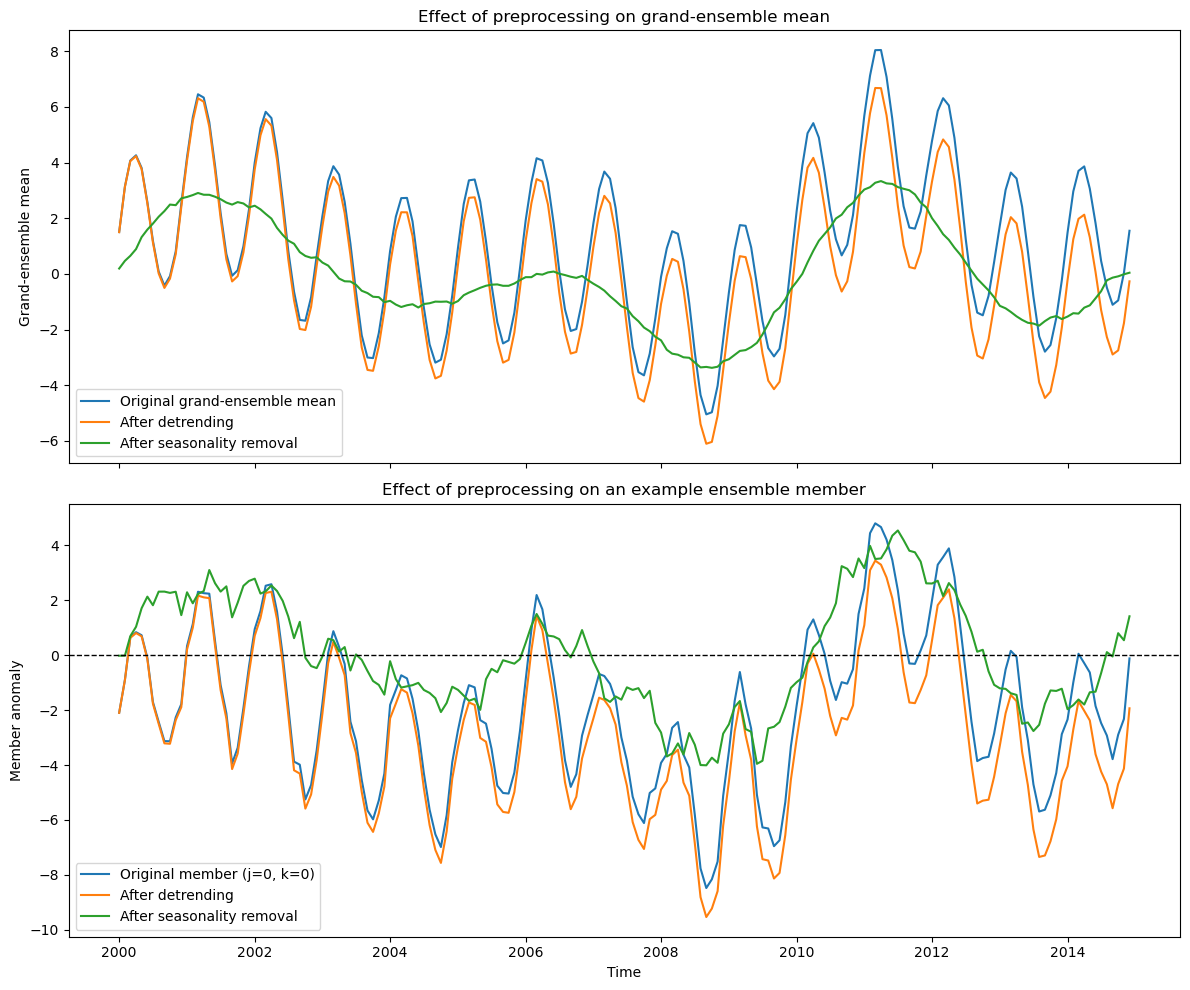

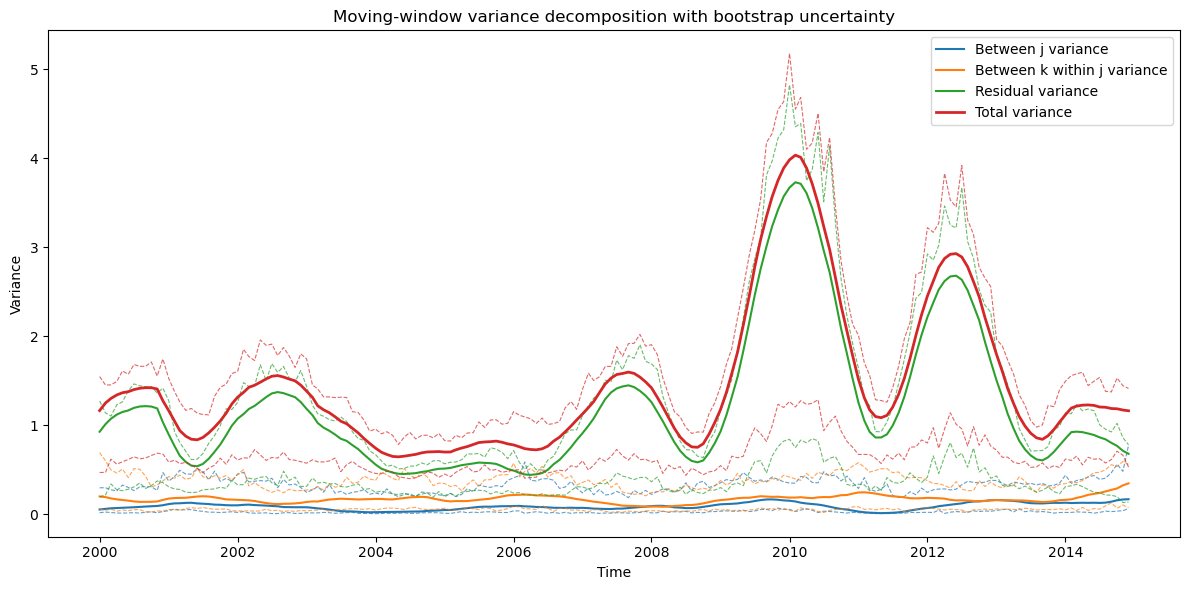

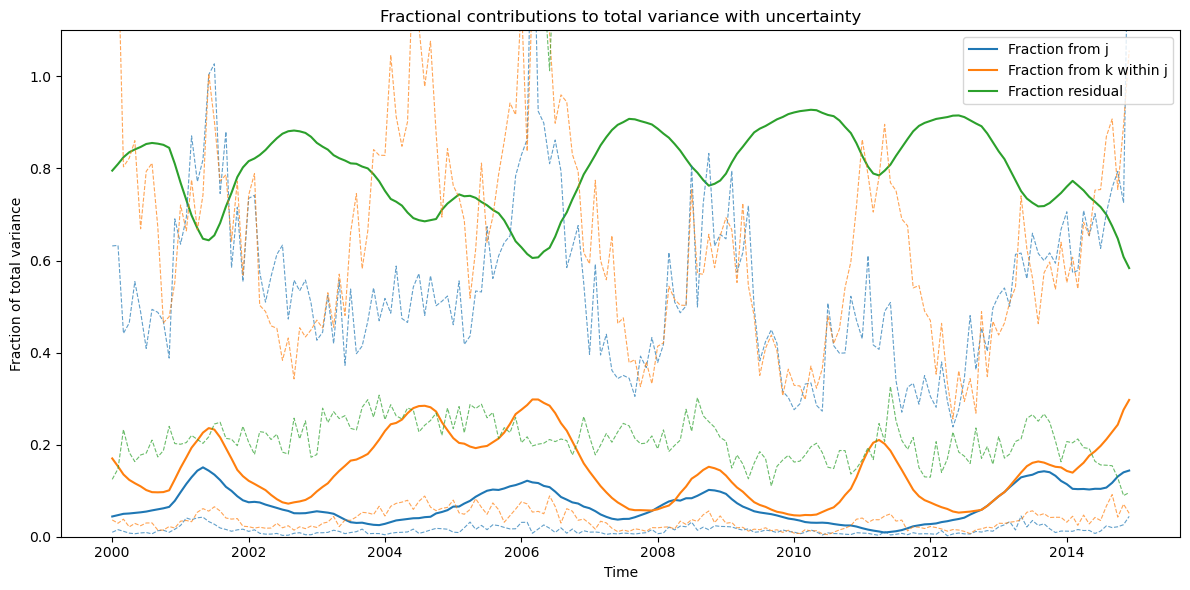


Average variance contributions
------------------------------
Mean between-j variance: 0.0863564240599459
Mean between-k-within-j variance: 0.16840047770514235
Mean residual variance: 1.208297977120612
Mean total variance: 1.4483531131667093
Mean fractional contribution from j: 0.06825922302089665
Mean fractional contribution from k within j: 0.144873336343311
Mean fractional residual contribution: 0.7987681014992991

Mean bootstrap confidence interval widths
-----------------------------------------
Between-j variance CI width: 0.3077119249909434
Between-k-within-j variance CI width: 0.3330138868179329
Residual variance CI width: 1.1262852266130954
Total variance CI width: 1.1433936558125637


In [6]:
# --------------------------------------------------------------
# Demonstrate preprocessing components separately
# --------------------------------------------------------------
g_detrended = remove_linear_trend(
    g,
    a=0.0,
    b=0.01 / 30.0,
)


g_preprocessed = remove_seasonal_cycle(
    g_detrended,
)
grand_ensemble_mean = g.mean(dim=["j", "k"])
grand_mean_detrended = g_detrended.mean(dim=["j", "k"])
grand_mean_final = g_preprocessed.mean(dim=["j", "k"])


# --------------------------------------------------------------
# Plot effect of preprocessing on both:
# (1) grand-ensemble mean;
# (2) one example member anomaly relative to the ensemble mean.
# --------------------------------------------------------------
example_member_original = g.sel(j=0, k=0)

example_member_detrended = g_detrended.sel(j=0, k=0)

example_member_final = g_preprocessed.sel(j=0, k=0)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 10),
    sharex=True,
)

# --------------------------------------------------------------
# Top panel: grand-ensemble mean evolution
# --------------------------------------------------------------
axes[0].plot(
    grand_ensemble_mean.t,
    grand_ensemble_mean,
    label="Original grand-ensemble mean",
)

axes[0].plot(
    grand_mean_detrended.t,
    grand_mean_detrended,
    label="After detrending",
)


axes[0].plot(
    grand_mean_final.t,
    grand_mean_final,
    label="After seasonality removal",
)

axes[0].set_title("Effect of preprocessing on grand-ensemble mean")
axes[0].set_ylabel("Grand-ensemble mean")
axes[0].legend()

# --------------------------------------------------------------
# Bottom panel: one example member through preprocessing
# --------------------------------------------------------------
axes[1].plot(
    example_member_original.t,
    example_member_original,
    label="Original member (j=0, k=0)",
)

axes[1].plot(
    example_member_detrended.t,
    example_member_detrended,
    label="After detrending",
)

axes[1].plot(
    example_member_final.t,
    example_member_final,
    label="After seasonality removal",
)

axes[1].axhline(
    0.0,
    color="k",
    linestyle="--",
    linewidth=1,
)

axes[1].set_title(
    "Effect of preprocessing on an example ensemble member"
)
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Member anomaly")
axes[1].legend()

plt.tight_layout()
plt.show()






# --------------------------------------------------------------
# Plot variance components with bootstrap confidence intervals
# --------------------------------------------------------------
plt.figure(figsize=(12, 6))

line_j, = plt.plot(
    result.t,
    result["variance_between_j"],
    label="Between j variance"
)

if "variance_between_j_ci_lower" in result:
    plt.plot(
        result.t,
        result["variance_between_j_ci_lower"],
        color=line_j.get_color(),
        linewidth=0.8,
        alpha=0.7,
        linestyle="--",
    )
    plt.plot(
        result.t,
        result["variance_between_j_ci_upper"],
        color=line_j.get_color(),
        linewidth=0.8,
        alpha=0.7,
        linestyle="--",
    )

line_k, = plt.plot(
    result.t,
    result["variance_between_k_within_j"],
    label="Between k within j variance"
)

if "variance_between_k_within_j_ci_lower" in result:
    plt.plot(
        result.t,
        result["variance_between_k_within_j_ci_lower"],
        color=line_k.get_color(),
        linewidth=0.8,
        alpha=0.7,
        linestyle="--",
    )
    plt.plot(
        result.t,
        result["variance_between_k_within_j_ci_upper"],
        color=line_k.get_color(),
        linewidth=0.8,
        alpha=0.7,
        linestyle="--",
    )

line_res, = plt.plot(
    result.t,
    result["residual_variance"],
    label="Residual variance"
)

if "residual_variance_ci_lower" in result:
    plt.plot(
        result.t,
        result["residual_variance_ci_lower"],
        color=line_res.get_color(),
        linewidth=0.8,
        alpha=0.7,
        linestyle="--",
    )
    plt.plot(
        result.t,
        result["residual_variance_ci_upper"],
        color=line_res.get_color(),
        linewidth=0.8,
        alpha=0.7,
        linestyle="--",
    )

line_tot, = plt.plot(
    result.t,
    result["total_variance"],
    label="Total variance",
    linewidth=2
)

if "total_variance_ci_lower" in result:
    plt.plot(
        result.t,
        result["total_variance_ci_lower"],
        color=line_tot.get_color(),
        linewidth=0.8,
        alpha=0.7,
        linestyle="--",
    )
    plt.plot(
        result.t,
        result["total_variance_ci_upper"],
        color=line_tot.get_color(),
        linewidth=0.8,
        alpha=0.7,
        linestyle="--",
    )

plt.title("Moving-window variance decomposition with bootstrap uncertainty")
plt.xlabel("Time")
plt.ylabel("Variance")
plt.legend()
plt.tight_layout()
plt.show()

# --------------------------------------------------------------
# Plot fractional variance contributions with approximate
# bootstrap confidence intervals
# --------------------------------------------------------------
plt.figure(figsize=(12, 6))

frac_j = (
    result["variance_between_j"]
    / result["total_variance"]
)

frac_k = (
    result["variance_between_k_within_j"]
    / result["total_variance"]
)

frac_res = (
    result["residual_variance"]
    / result["total_variance"]
)

line_j, = plt.plot(
    result.t,
    frac_j,
    label="Fraction from j"
)

line_k, = plt.plot(
    result.t,
    frac_k,
    label="Fraction from k within j"
)

line_res, = plt.plot(
    result.t,
    frac_res,
    label="Fraction residual"
)

# --------------------------------------------------------------
# Approximate confidence intervals for fractional contributions
#
# These are formed by dividing the lower and upper confidence
# bounds of each variance component by the corresponding upper
# and lower bounds of the total variance. This is conservative
# and avoids understating uncertainty in the fractions.
# --------------------------------------------------------------
if (
    "variance_between_j_ci_lower" in result
    and "total_variance_ci_lower" in result
):
    frac_j_lower = (
        result["variance_between_j_ci_lower"]
        / result["total_variance_ci_upper"]
    )

    frac_j_upper = (
        result["variance_between_j_ci_upper"]
        / result["total_variance_ci_lower"]
    )

    plt.plot(
        result.t,
        frac_j_lower,
        color=line_j.get_color(),
        linewidth=0.8,
        alpha=0.7,
        linestyle="--",
    )

    plt.plot(
        result.t,
        frac_j_upper,
        color=line_j.get_color(),
        linewidth=0.8,
        alpha=0.7,
        linestyle="--",
    )

if (
    "variance_between_k_within_j_ci_lower" in result
    and "total_variance_ci_lower" in result
):
    frac_k_lower = (
        result["variance_between_k_within_j_ci_lower"]
        / result["total_variance_ci_upper"]
    )

    frac_k_upper = (
        result["variance_between_k_within_j_ci_upper"]
        / result["total_variance_ci_lower"]
    )

    plt.plot(
        result.t,
        frac_k_lower,
        color=line_k.get_color(),
        linewidth=0.8,
        alpha=0.7,
        linestyle="--",
    )

    plt.plot(
        result.t,
        frac_k_upper,
        color=line_k.get_color(),
        linewidth=0.8,
        alpha=0.7,
        linestyle="--",
    )

if (
    "residual_variance_ci_lower" in result
    and "total_variance_ci_lower" in result
):
    frac_res_lower = (
        result["residual_variance_ci_lower"]
        / result["total_variance_ci_upper"]
    )

    frac_res_upper = (
        result["residual_variance_ci_upper"]
        / result["total_variance_ci_lower"]
    )

    plt.plot(
        result.t,
        frac_res_lower,
        color=line_res.get_color(),
        linewidth=0.8,
        alpha=0.7,
        linestyle="--",
    )

    plt.plot(
        result.t,
        frac_res_upper,
        color=line_res.get_color(),
        linewidth=0.8,
        alpha=0.7,
        linestyle="--",
    )

plt.title("Fractional contributions to total variance with uncertainty")
plt.xlabel("Time")
plt.ylabel("Fraction of total variance")
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.show()


# --------------------------------------------------------------
# Summarize average variance contributions
# --------------------------------------------------------------
print("\nAverage variance contributions")
print("------------------------------")

print(
    "Mean between-j variance:",
    float(result["variance_between_j"].mean())
)

print(
    "Mean between-k-within-j variance:",
    float(result["variance_between_k_within_j"].mean())
)

print(
    "Mean residual variance:",
    float(result["residual_variance"].mean())
)

print(
    "Mean total variance:",
    float(result["total_variance"].mean())
)

print(
    "Mean fractional contribution from j:",
    float(result["fraction_variance_between_j"].mean())
)

print(
    "Mean fractional contribution from k within j:",
    float(result["fraction_variance_between_k_within_j"].mean())
)

print(
    "Mean fractional residual contribution:",
    float(result["fraction_residual_variance"].mean())
)

# --------------------------------------------------------------
# Summarize mean bootstrap interval widths
# --------------------------------------------------------------
if "variance_between_j_ci_upper" in result:
    print("\nMean bootstrap confidence interval widths")
    print("-----------------------------------------")

    print(
        "Between-j variance CI width:",
        float(
            (
                result["variance_between_j_ci_upper"]
                - result["variance_between_j_ci_lower"]
            ).mean()
        )
    )

    print(
        "Between-k-within-j variance CI width:",
        float(
            (
                result["variance_between_k_within_j_ci_upper"]
                - result["variance_between_k_within_j_ci_lower"]
            ).mean()
        )
    )

    print(
        "Residual variance CI width:",
        float(
            (
                result["residual_variance_ci_upper"]
                - result["residual_variance_ci_lower"]
            ).mean()
        )
    )

    print(
        "Total variance CI width:",
        float(
            (
                result["total_variance_ci_upper"]
                - result["total_variance_ci_lower"]
            ).mean()
        )
    )

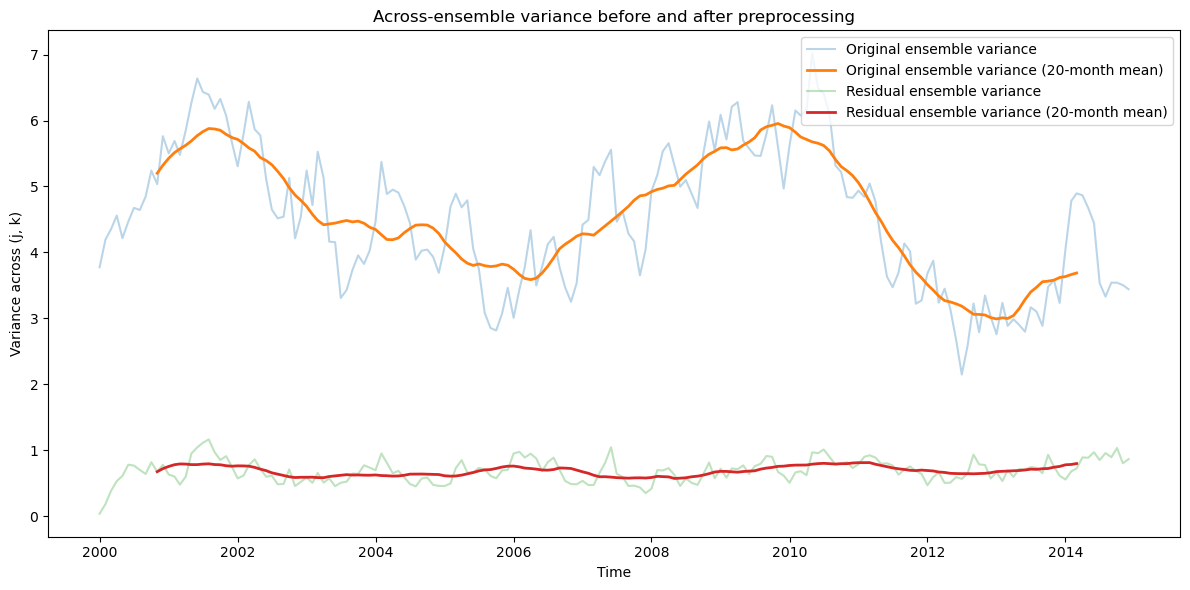


Across-ensemble variance diagnostics
------------------------------------
Mean original ensemble variance: 4.528369091590319
Mean residual ensemble variance: 0.6869476341716343
Std. dev. of original ensemble variance through time: 1.0531596050903358
Std. dev. of residual ensemble variance through time: 0.17294327142348553


In [10]:

# --------------------------------------------------------------
# Compare across-ensemble variance through time before and after
# preprocessing
# --------------------------------------------------------------
ensemble_variance_original = g.var(
    dim=["j", "k"],
    ddof=1,
)

ensemble_variance_residual = g_preprocessed.var(
    dim=["j", "k"],
    ddof=1,
)

# Optional smoothing to make slow non-stationary structure cleare.
# - here, we use the MBB window width.
rolling_window = result.attrs["window_width"]

ensemble_variance_original_smooth = (
    ensemble_variance_original
    .rolling(t=rolling_window, center=True)
    .mean()
)

ensemble_variance_residual_smooth = (
    ensemble_variance_residual
    .rolling(t=rolling_window, center=True)
    .mean()
)

plt.figure(figsize=(12, 6))

plt.plot(
    ensemble_variance_original.t,
    ensemble_variance_original,
    alpha=0.3,
    label="Original ensemble variance",
)

plt.plot(
    ensemble_variance_original_smooth.t,
    ensemble_variance_original_smooth,
    linewidth=2,
    label=f"Original ensemble variance ({rolling_window}-month mean)",
)

plt.plot(
    ensemble_variance_residual.t,
    ensemble_variance_residual,
    alpha=0.3,
    label="Residual ensemble variance",
)

plt.plot(
    ensemble_variance_residual_smooth.t,
    ensemble_variance_residual_smooth,
    linewidth=2,
    label=f"Residual ensemble variance ({rolling_window}-month mean)",
)

plt.title("Across-ensemble variance before and after preprocessing")
plt.xlabel("Time")
plt.ylabel("Variance across (j, k)")
plt.legend()
plt.tight_layout()
plt.show()

# --------------------------------------------------------------
# Summarize reduction in non-stationary variance
# --------------------------------------------------------------
print("\nAcross-ensemble variance diagnostics")
print("------------------------------------")

print(
    "Mean original ensemble variance:",
    float(ensemble_variance_original.mean())
)

print(
    "Mean residual ensemble variance:",
    float(ensemble_variance_residual.mean())
)

print(
    "Std. dev. of original ensemble variance through time:",
    float(ensemble_variance_original.std())
)

print(
    "Std. dev. of residual ensemble variance through time:",
    float(ensemble_variance_residual.std())
)



Relative non-stationarity diagnostics
-------------------------------------
Original variance: mean = 4.528369091590319
Original variance: std through time = 1.0531596050903358
Original relative non-stationarity = 0.23256929454937084
Residual variance: mean = 0.6869476341716343
Residual variance: std through time = 0.17294327142348553
Residual relative non-stationarity = 0.2517561205841136
Fractional reduction in relative non-stationarity = -0.08249939473703694


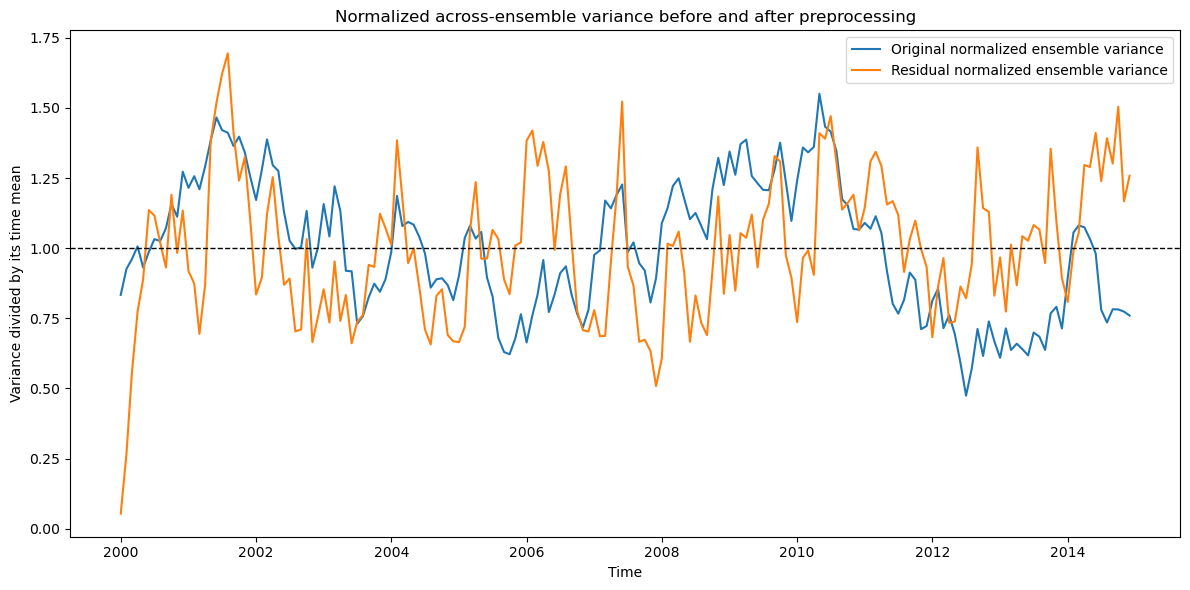

In [13]:

# --------------------------------------------------------------
# Compare non-stationarity relative to mean variance level
# --------------------------------------------------------------
# The standard deviation through time of the ensemble variance
# can be normalized by its mean value. This gives a dimensionless
# measure of relative non-stationarity.
# --------------------------------------------------------------
mean_var_original = float(ensemble_variance_original.mean())
mean_var_residual = float(ensemble_variance_residual.mean())

std_var_original = float(ensemble_variance_original.std())
std_var_residual = float(ensemble_variance_residual.std())

relative_nonstationarity_original = (
    std_var_original / mean_var_original
)

relative_nonstationarity_residual = (
    std_var_residual / mean_var_residual
)

print("\nRelative non-stationarity diagnostics")
print("-------------------------------------")

print(
    "Original variance: mean =",
    mean_var_original
)

print(
    "Original variance: std through time =",
    std_var_original
)

print(
    "Original relative non-stationarity =",
    relative_nonstationarity_original
)

print(
    "Residual variance: mean =",
    mean_var_residual
)

print(
    "Residual variance: std through time =",
    std_var_residual
)

print(
    "Residual relative non-stationarity =",
    relative_nonstationarity_residual
)

print(
    "Fractional reduction in relative non-stationarity =",
    1.0
    - (
        relative_nonstationarity_residual
        / relative_nonstationarity_original
    )
)

# --------------------------------------------------------------
# Visualize relative variance changes through time
# --------------------------------------------------------------
normalized_variance_original = (
    ensemble_variance_original / mean_var_original
)

normalized_variance_residual = (
    ensemble_variance_residual / mean_var_residual
)

plt.figure(figsize=(12, 6))

plt.plot(
    normalized_variance_original.t,
    normalized_variance_original,
    label="Original normalized ensemble variance",
)

plt.plot(
    normalized_variance_residual.t,
    normalized_variance_residual,
    label="Residual normalized ensemble variance",
)

plt.axhline(
    1.0,
    color="k",
    linestyle="--",
    linewidth=1,
)

plt.title(
    "Normalized across-ensemble variance before and after preprocessing"
)
plt.xlabel("Time")
plt.ylabel("Variance divided by its time mean")
plt.legend()
plt.tight_layout()
plt.show()



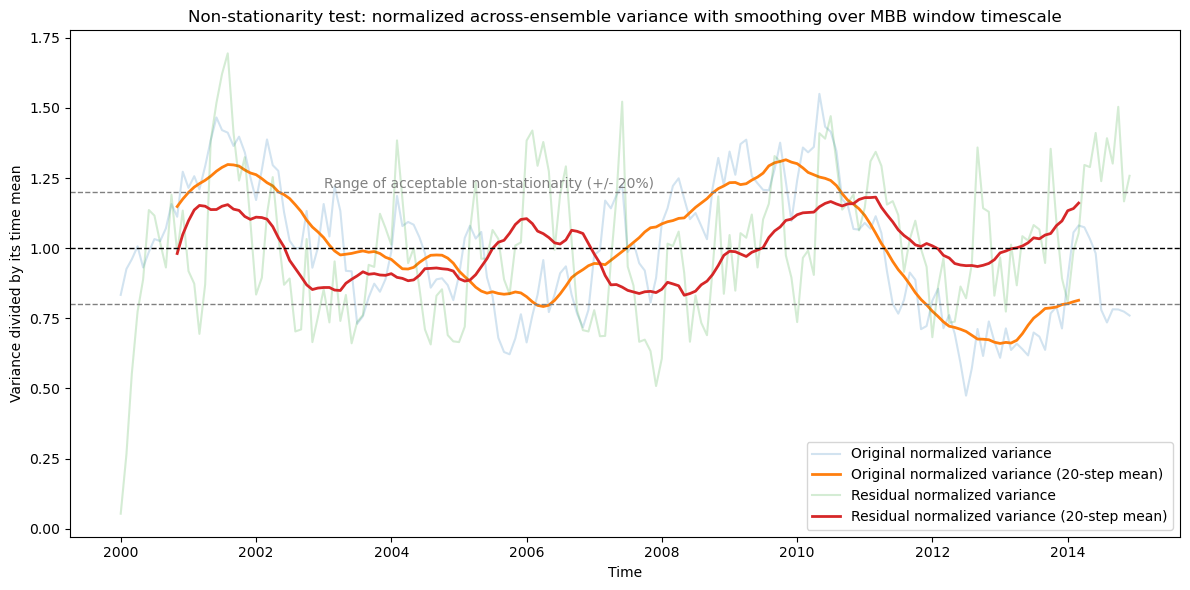

In [14]:
# --------------------------------------------------------------
# Add smoothing using the effective MBB window width
# --------------------------------------------------------------
# This highlights variability on the time scale that the moving-
# block bootstrap treats as approximately independent.
# --------------------------------------------------------------
mbb_window = result.attrs["window_width"]


normalized_variance_original_smooth = (
    normalized_variance_original
    .rolling(t=mbb_window, center=True)
    .mean()
)

normalized_variance_residual_smooth = (
    normalized_variance_residual
    .rolling(t=mbb_window, center=True)
    .mean()
)

plt.figure(figsize=(12, 6))

plt.plot(
    normalized_variance_original.t,
    normalized_variance_original,
    alpha=0.2,
    label="Original normalized variance",
)

plt.plot(
    normalized_variance_original_smooth.t,
    normalized_variance_original_smooth,
    linewidth=2,
    label=f"Original normalized variance ({mbb_window}-step mean)",
)

plt.plot(
    normalized_variance_residual.t,
    normalized_variance_residual,
    alpha=0.2,
    label="Residual normalized variance",
)

plt.plot(
    normalized_variance_residual_smooth.t,
    normalized_variance_residual_smooth,
    linewidth=2,
    label=f"Residual normalized variance ({mbb_window}-step mean)",
)

plt.axhline(
    1.0,
    color="k",
    linestyle="--",
    linewidth=1,
)

plt.axhline(
    0.8,
    color="gray",
    linestyle="--",
    linewidth=1,
)

plt.axhline(
    1.2,
    color="gray",
    linestyle="--",
    linewidth=1,
)

plt.text(
    normalized_variance_original.t.values[int(len(normalized_variance_original.t) * 0.2)],
    1.205,
    "Range of acceptable non-stationarity (+/- 20%)",
    color="gray",
    fontsize=10,
    verticalalignment="bottom",
)

plt.title(
    "Non-stationarity test: normalized across-ensemble variance with smoothing over MBB window timescale"
)
plt.xlabel("Time")
plt.ylabel("Variance divided by its time mean")
plt.legend()
plt.tight_layout()
plt.show()

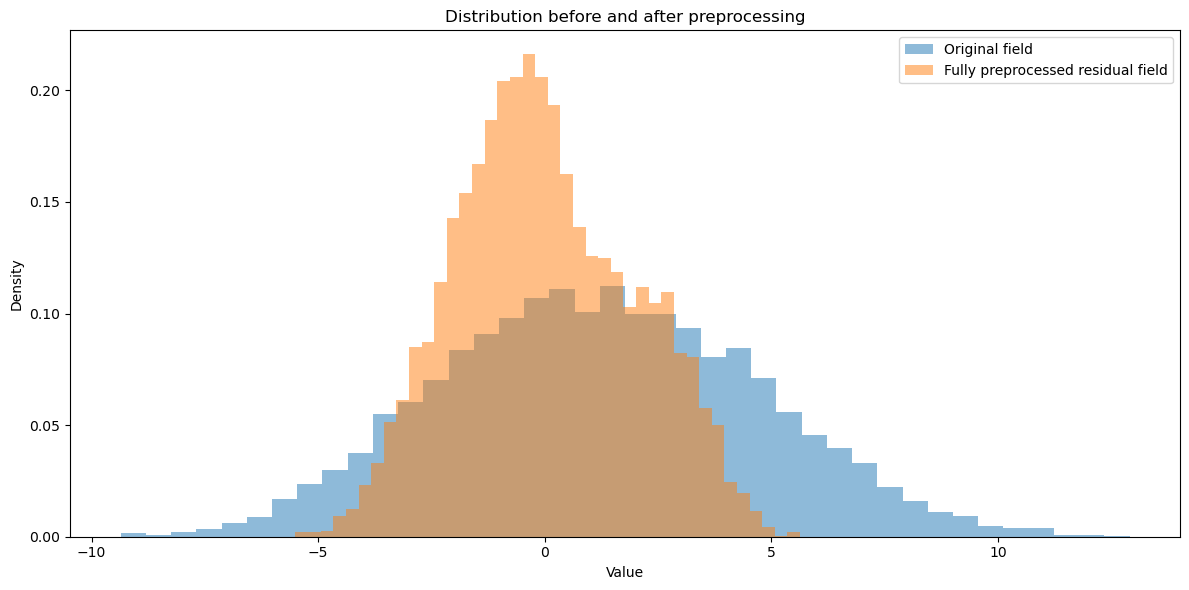

In [15]:
# --------------------------------------------------------------
# Compare the distributions of the original and final residual
# fields across all j, k, t values
# --------------------------------------------------------------
plt.figure(figsize=(12, 6))

plt.hist(
    g.values.ravel(),
    bins=40,
    alpha=0.5,
    density=True,
    label="Original field",
)

plt.hist(
    g_preprocessed.values.ravel(),
    bins=40,
    alpha=0.5,
    density=True,
    label="Fully preprocessed residual field",
)

plt.title("Distribution before and after preprocessing")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

